# Task 3: Customer Churn Prediction (Bank Customers)

## Introduction & Problem Statement
Customer churn — when customers leave a service — is a major concern for banks. Identifying **at-risk customers** before they leave allows the bank to take proactive retention actions.

### Objective:
Build a classification model to predict whether a bank customer will **exit (churn)** based on their profile and account details.

### Dataset:
The **Churn Modelling Dataset** (10,000 bank customers with 14 features).

In [1]:
# ── Install & import libraries ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded!')

All libraries loaded!


## 1. Dataset Understanding & Description



In [2]:
from google.colab import files
uploaded = files.upload()  # Churn_Modelling.csv upload karo
df = pd.read_csv('Churn_Modelling.csv')

Saving Churn_Modelling.csv to Churn_Modelling.csv


## 2. Data Cleaning & Preparation

In [3]:
# ── Basic info ───────────────────────────────────────────────────────────────
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

=== Missing Values ===
RowNumber          0
CustomerId         0
Surname

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [4]:
# ── Drop irrelevant columns ──────────────────────────────────────────────────
df_model = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
print('Columns after dropping IDs:', df_model.columns.tolist())

Columns after dropping IDs: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


## 3. Exploratory Data Analysis (EDA)

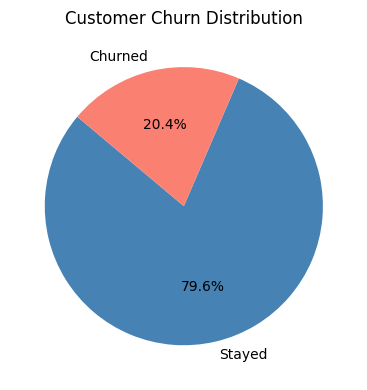

Exited
0    7963
1    2037


In [5]:
# ── Churn distribution ───────────────────────────────────────────────────────
plt.figure(figsize=(5, 4))
churn_counts = df_model['Exited'].value_counts()
plt.pie(churn_counts, labels=['Stayed', 'Churned'], autopct='%1.1f%%',
        colors=['steelblue', 'salmon'], startangle=140)
plt.title('Customer Churn Distribution')
plt.tight_layout()
plt.show()
print(churn_counts.to_string())

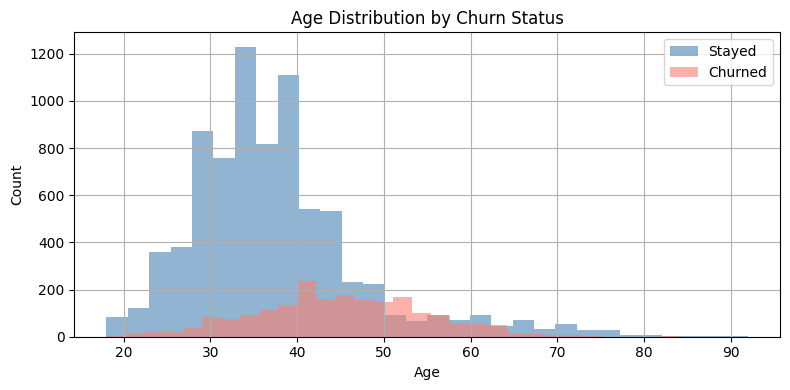

Insight: Older customers (40-60) are more likely to churn.


In [6]:
# ── Age distribution by Churn ────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
df_model[df_model['Exited']==0]['Age'].hist(bins=30, alpha=0.6, label='Stayed', color='steelblue')
df_model[df_model['Exited']==1]['Age'].hist(bins=30, alpha=0.6, label='Churned', color='salmon')
plt.title('Age Distribution by Churn Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()
print('Insight: Older customers (40-60) are more likely to churn.')

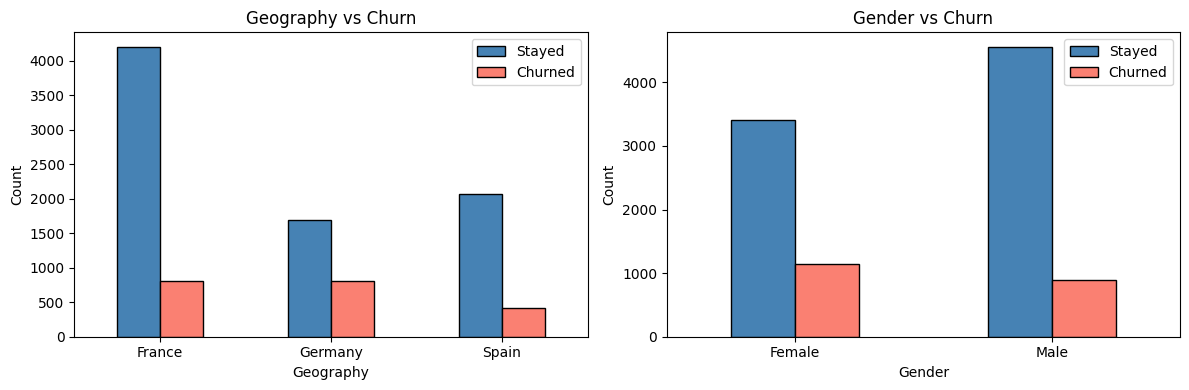

Insight: German customers and female customers have higher churn rates.


In [7]:
# ── Geography & Gender vs Churn ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Geography
geo_ct = pd.crosstab(df_model['Geography'], df_model['Exited'])
geo_ct.columns = ['Stayed', 'Churned']
geo_ct.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Geography vs Churn')
axes[0].set_xlabel('Geography')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Gender
gen_ct = pd.crosstab(df_model['Gender'], df_model['Exited'])
gen_ct.columns = ['Stayed', 'Churned']
gen_ct.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], edgecolor='black')
axes[1].set_title('Gender vs Churn')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
print('Insight: German customers and female customers have higher churn rates.')

<Figure size 600x400 with 0 Axes>

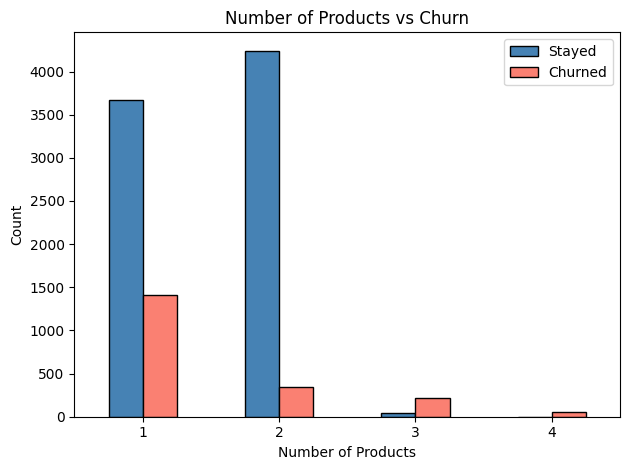

Insight: Customers with 3-4 products have extremely high churn — may indicate product dissatisfaction.


In [8]:
# ── Number of Products vs Churn ──────────────────────────────────────────────
plt.figure(figsize=(6, 4))
prod_ct = pd.crosstab(df_model['NumOfProducts'], df_model['Exited'])
prod_ct.columns = ['Stayed', 'Churned']
prod_ct.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Number of Products vs Churn')
plt.xlabel('Number of Products')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print('Insight: Customers with 3-4 products have extremely high churn — may indicate product dissatisfaction.')

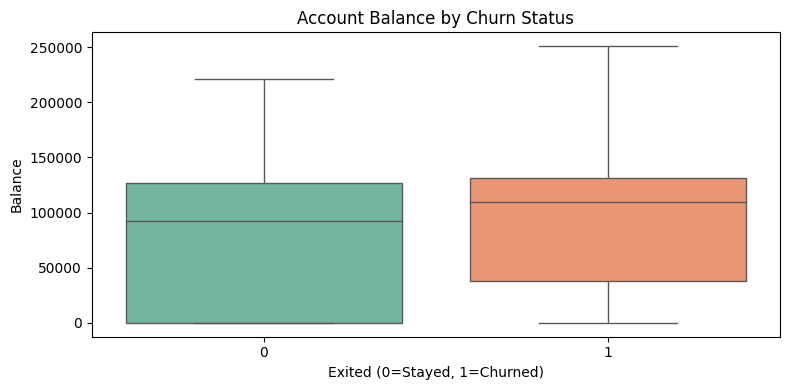

In [9]:
# ── Balance distribution by Churn ────────────────────────────────────────────
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_model, x='Exited', y='Balance', palette='Set2')
plt.title('Account Balance by Churn Status')
plt.xlabel('Exited (0=Stayed, 1=Churned)')
plt.ylabel('Balance')
plt.tight_layout()
plt.show()

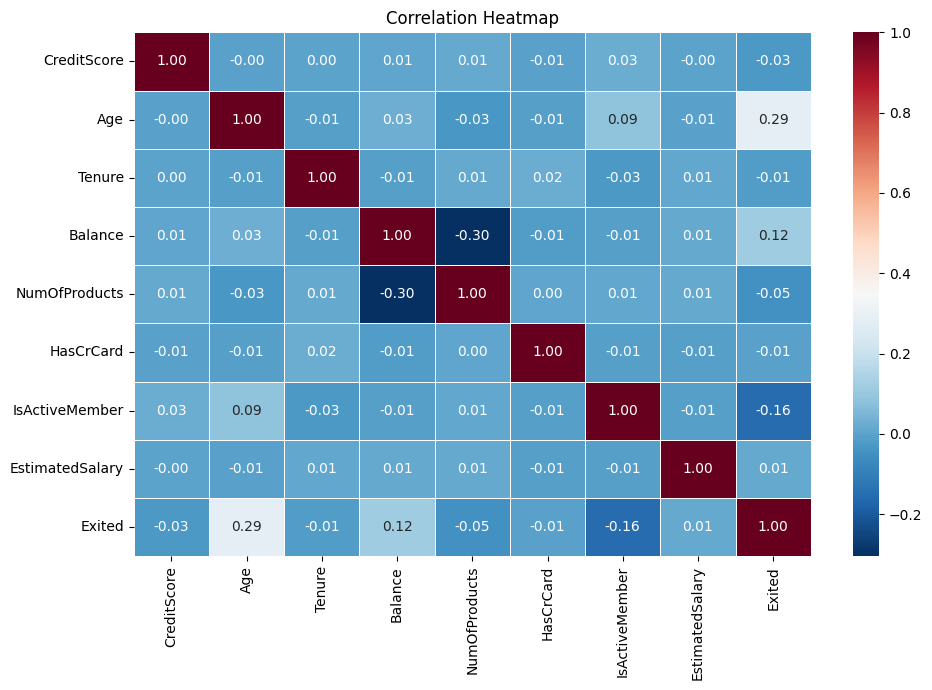

In [10]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
num_df = df_model[['CreditScore', 'Age', 'Tenure', 'Balance',
                    'NumOfProducts', 'HasCrCard', 'IsActiveMember',
                    'EstimatedSalary', 'Exited']]
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='RdBu_r', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Encoding Categorical Features

In [11]:
# ── Label Encoding for binary categories ─────────────────────────────────────
le = LabelEncoder()
df_model['Gender'] = le.fit_transform(df_model['Gender'])  # Male=1, Female=0

# One-Hot Encoding for Geography (3 categories)
df_model = pd.get_dummies(df_model, columns=['Geography'], drop_first=True)

print('Columns after encoding:', df_model.columns.tolist())
print('\nSample rows:')
df_model.head()

Columns after encoding: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']

Sample rows:


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


## 5. Model Training & Evaluation

In [12]:
# ── Split features and target ────────────────────────────────────────────────
X = df_model.drop(columns='Exited')
y = df_model['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 8000 | Test: 2000


In [13]:
# ── Train models ─────────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=8,
                                                   random_state=42, n_jobs=-1)
}

results = {}
for name, model in models.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_te)[:, 1])
    results[name] = {'model': model, 'pred': y_pred, 'acc': acc, 'auc': auc,
                     'X_te': X_te}
    print(f'{name}: Accuracy={acc:.4f} | ROC-AUC={auc:.4f}')

Logistic Regression: Accuracy=0.8080 | ROC-AUC=0.7748
Decision Tree: Accuracy=0.8595 | ROC-AUC=0.8390
Random Forest: Accuracy=0.8690 | ROC-AUC=0.8663


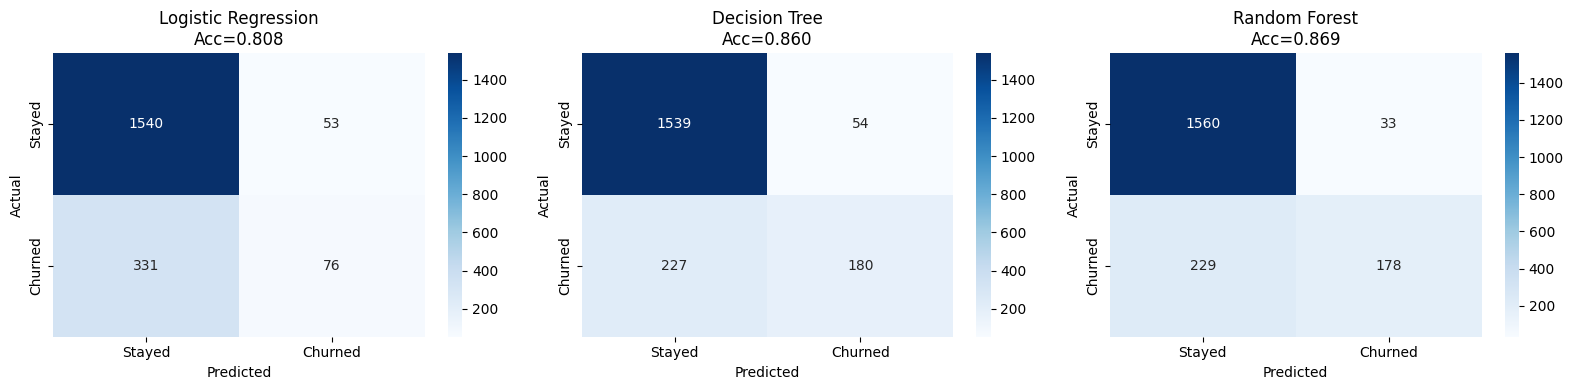

In [14]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stayed', 'Churned'],
                yticklabels=['Stayed', 'Churned'])
    ax.set_title(f'{name}\nAcc={res["acc"]:.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

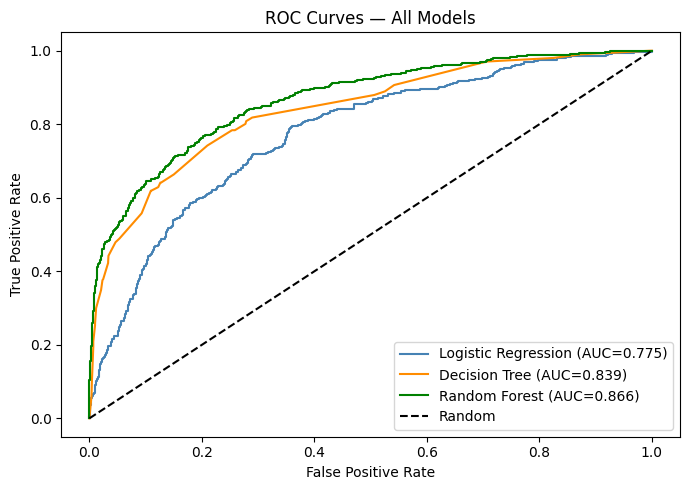

In [15]:
# ── ROC Curves ───────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 5))
colors = ['steelblue', 'darkorange', 'green']
for (name, res), color in zip(results.items(), colors):
    proba = res['model'].predict_proba(res['X_te'])[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, color=color, label=f"{name} (AUC={res['auc']:.3f})")
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Feature Importance Analysis

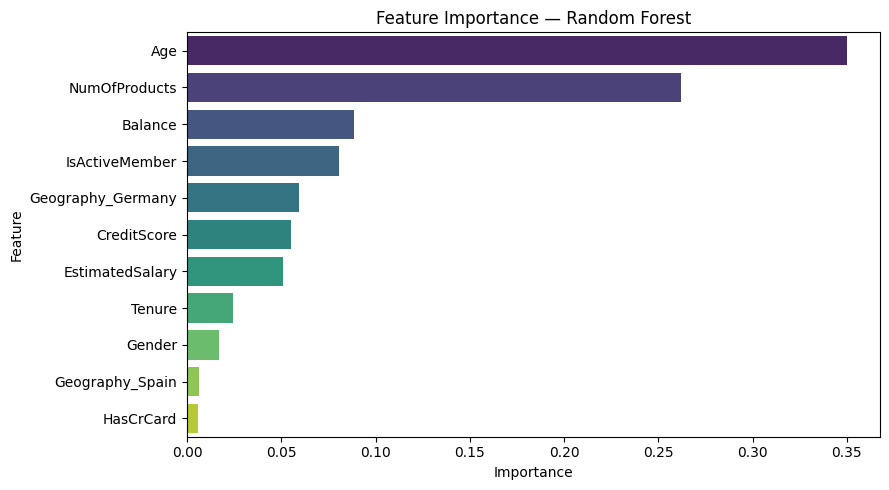


Top Features:
          Feature  Importance
              Age    0.350122
    NumOfProducts    0.262048
          Balance    0.088349
   IsActiveMember    0.080826
Geography_Germany    0.059513
      CreditScore    0.055092
  EstimatedSalary    0.050744
           Tenure    0.024533


In [16]:
# ── Random Forest Feature Importance ─────────────────────────────────────────
rf = results['Random Forest']['model']
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

print('\nTop Features:')
print(feat_imp.head(8).to_string(index=False))

## 7. Conclusion

**Random Forest** achieved the best performance with the highest accuracy and AUC score, followed by Decision Tree and Logistic Regression.

**Key Findings from Feature Importance Analysis:**
- **Age** is the most influential factor (importance: 0.35) — older customers are significantly more likely to churn
- **Number of Products** is the second strongest predictor (0.26) — customers with 3-4 products show surprisingly high churn rates
- **Account Balance** (0.09) and **Active Membership Status** (0.09) are equally important factors
- **Geography — Germany** (0.06) indicates that German customers churn at a noticeably higher rate than French or Spanish customers

**Key Insights:**
- Customers aged **40–60** combined with inactive account status represent the highest churn risk group
- Customers holding **3 or more products** show unexpectedly high churn — this may indicate product dissatisfaction or poor customer experience
- **Inactive members** are nearly twice as likely to leave the bank compared to active members

**Business Recommendation:**
The bank should prioritize retention efforts towards inactive members aged 40–60, especially those based in Germany. Personalized offers, loyalty rewards, and proactive customer engagement strategies should be deployed for this high-risk segment before they decide to leave.